In [ ]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
from IPython.display import display, Math
import matplotlib as mpl


figsize(17, 3.5)
mpl.rcParams['agg.path.chunksize'] = 10000

In [24]:
import numpy as np
from numpy.random import normal
import matplotlib.pyplot as plt
from scipy import constants
#from commpy.utilities import signal_power, upsample
#from optic.models import mzm, photodiode
#from optic.plot import eyediagram
#from optic.core import parameters

## Receptores ópticos e ruído
---

## Sumário
---
- [Introdução](#introdução)
- [Ruído de disparo](ruído-de-disparo)
- [Ruído térmico](ruído-térmico)

### Introdução
---

<center><img src="https://github.com/Medupl/CoppeliaSim/blob/main/images/Optic/receptor%20optico.png?raw=true" width="55%"/></center>
$$\text{Fonte: Anotações do professor Edson}$$


### Introdução
---

No cenário ideal de uma comunicação óptica, um sinal gerado ou modulado na origem seria transmitido pela fibra até um detector óptico, como um fotodiodo, que geraria pulsos elétricos equivalentes e possibilitaria a recuperação da informação transmitida. Entretanto, no ambiente real, diversas fontes de ruído surgem no sistema, podendo limitar ou até inviabilizar a transmissão e a correta detecção dos dados.


No funcionamento ideal do fotorreceptor, teríamos uma potência do sinal em função do tempo, $P_{in}(t)$, que geraria uma corrente proporcional, utilizada para recuperar o sinal, expressa por:

$$
I_p(t) = R_d \cdot P_{in}(t)
$$

onde:
- $I_p(t)$ é a corrente elétrica gerada,
- $R_d$ é a responsividade do fotodiodo.

Devido às interferências causadas por limitações no equipamento receptor (como imperfeições do fotodiodo) e efeitos térmicos no sistema, dois tipos de ruído devem ser considerados. Esses ruídos geram **correntes adicionais** que se somam à corrente associada ao sinal útil, resultando em uma corrente total:

- **Ruído de disparo** – relacionado à natureza estatística da detecção de fótons.
- **Ruído térmico** – proveniente da agitação térmica dos portadores de carga no receptor.

### Ruído de Disparo
---

Entretanto, o processo físico de detecção no fotodiodo pode gerar ruídos devido às falhas aleatórias na captação dos elétrons, conhecido como ruído de disparo $I_s(t)$, que possui natureza aditiva. Assim, a corrente total pode ser representada por:

$$
I(t) = I_p(t) + I_s(t)
$$

Esse ruído de disparo segue uma distribuição probabilística Poissoniana, mas para sinais intensos, é bem aproximado por uma função gaussiana e estacionária. Isso facilita seus cálculos, pois basta conhecer sua média e variância, podendo ser considerado um ruído branco gaussiano. Sua densidade espectral de potência é constante:

$$
S_{is}(f) = q \overline{I_d}
$$

e a potência do ruído de disparo corresponderá a sua variância $\sigma_{is}^2$que é dada por:

$$
\sigma_{is}^2 = 2q\overline{I_d}B
$$

onde:
- $q$ é a carga do elétron,
- $\overline{I_d}$ é a corrente média,
- $B$ é a largura de banda do receptor.

Além disso, o fotodiodo também apresenta outro tipo de ruído físico: a corrente de escuro $I_d$, que é a corrente gerada mesmo na ausência de luz. Essa corrente também contribui de forma aditiva para o ruído de disparo, alterando a expressão da variância para:

$$
\sigma_{is}^2 = 2q(\overline{I_d} + I_d)B
$$






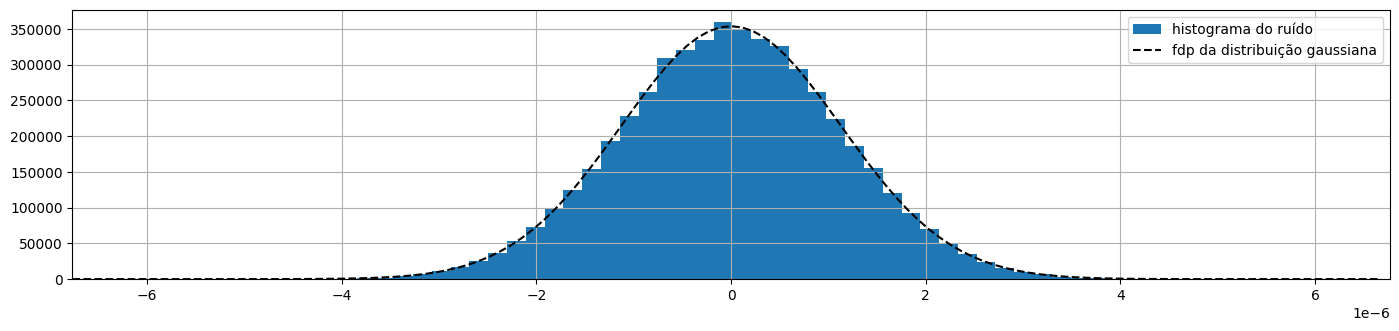

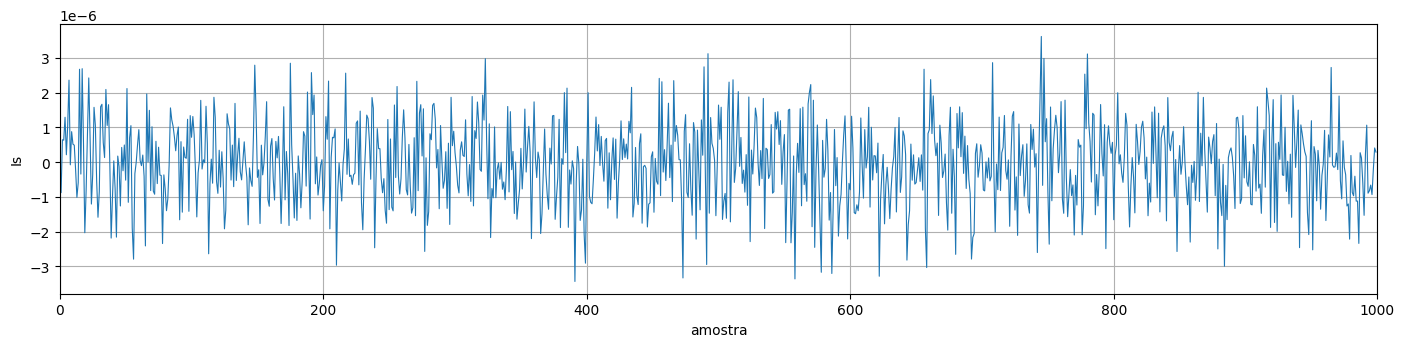

In [ ]:
Pin_dBm = -1   # potência óptica média em dBm
Rd  = 0.5      # responsividade em A/W
Id  = 100e-9   # corrente de escuro em nA
B   = 10e9     # banda do receptor em Hz

q  = constants.value('elementary charge') # carga elementar do elétron

Pin = 10**(Pin_dBm/10)*1e-3 # potência óptica média em W
Ip  = Rd*Pin

# ruído de disparo (ruído gaussiano branco)
Namostras = 100000

σ2_s = 2*q*(Ip + Id)*B  # variância
μ    = 0                # média

σ = np.sqrt(σ2_s)
Is = normal(μ, σ, Namostras)

def gaussian(x, μ, σ):
    return np.exp(-((x - μ)**2)/(2*σ**2))/np.sqrt(2*np.pi*σ**2)
plt.figure()
plt.hist(Is,51, density=True, label = 'histograma do ruído');
plt.grid()

x   = np.arange(-6*σ,6*σ, σ/10)
fdp = gaussian(x,μ,σ)

plt.plot(x,fdp,'k--',label ='fdp da distribuição gaussiana');
plt.legend();
plt.xlim(-6*σ,6*σ);

# plotas as primeiras 1000 amostras
plt.figure()
plt.plot(Is[0:1000],linewidth = 0.8);
plt.xlim(0,1000)
plt.ylabel('Is')
plt.xlabel('amostra')
plt.grid()

<IPython.core.display.Math object>

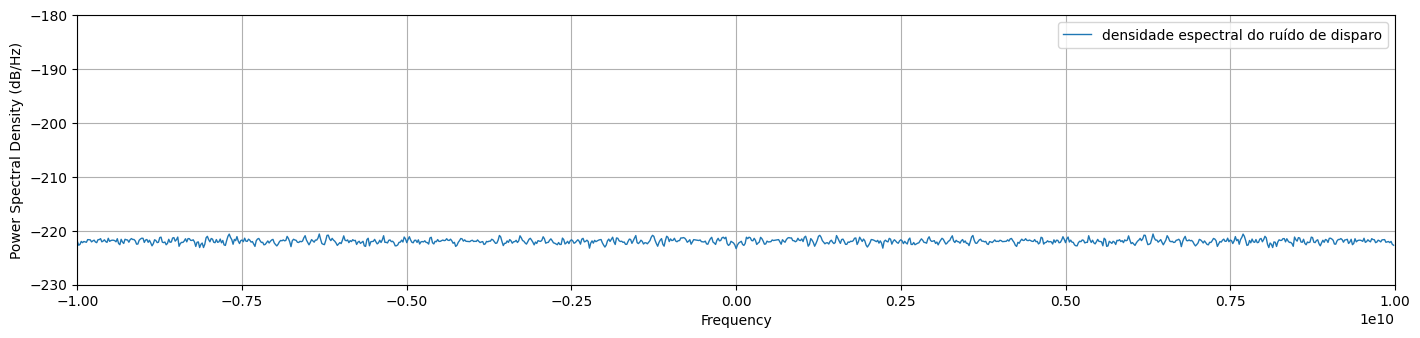

In [ ]:
fa = 20e9   # frequência de amostragem considerada

plt.figure()
plt.xlim(-fa/2, fa/2)
plt.ylim(-230, -180)
plt.psd(Is, Fs=fa, label='densidade espectral do ruído de disparo',\
                   linewidth=1,  sides='twosided', NFFT=1024); # estima densidade espectral de potência do sinal
plt.legend()

display(Math('S_{i_s}(f) = %.2f \;\mathrm{dBW/Hz}'%(10*np.log10(σ2_s/(2*B)))))


### Ruído Térmico
---

O **ruído térmico**, gerado pela agitação térmica dos elétrons no receptor, sendo independente do sinal transmitido. Esse ruído também possui natureza aditiva, podendo ser modelado como um processo estocástico, gaussiano e estacionário, e portanto também classificado como ruído branco gaussiano.

A corrente total considerando todos os ruídos é:

$$
I(t) = I_p(t) + I_s(t) + I_T(t)
$$

A densidade espectral de potência do ruído térmico é constante e dada por:

$$
S_T(f) = \frac{2K_bT}{R_L}
$$

e a potência do ruído corresponde a sua variância $\sigma_T^2$ que é dado por:

$$
\sigma_T^2 = \left( \frac{4K_bT}{R_L} \right) B
$$

onde:
- $K_b$ é a constante de Boltzmann,
- $ T$ é a temperatura em Kelvin,
- $R_L$ é o resistor de carga do circuito.

Em nosso circuito, os amplificadores também podem introduzir ruídos térmicos adicionais. Esses ruídos são genericamente caracterizados pelo fator de ruído $F_n$, que introduz um ganho multiplicativo à expressão da variância do ruído térmico, resultando em:

$$
\sigma_T^2 = \left( \frac{4K_bT}{R_L} \right) F_n B
$$

<IPython.core.display.Math object>

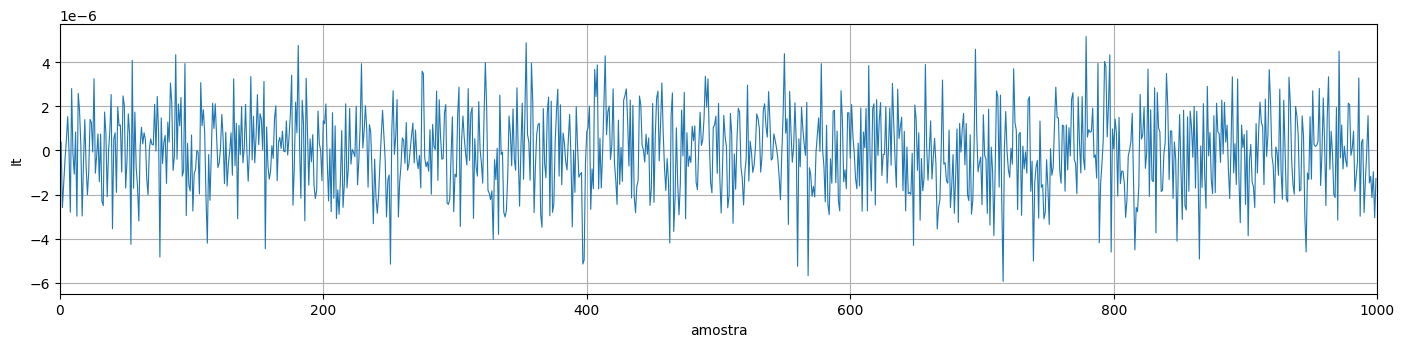

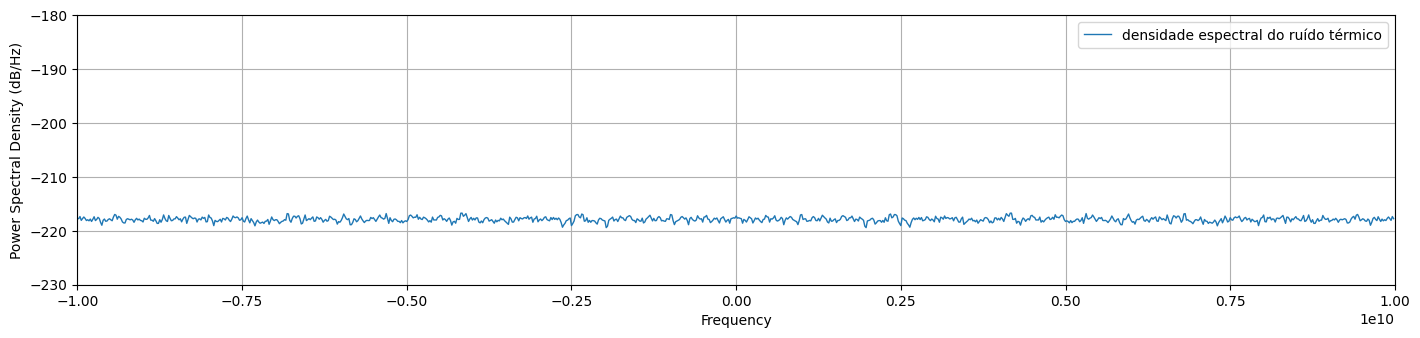

In [ ]:
Tc = 25           # temperatura em Celsius
B  = 10e9         # banda do receptor
RL = 50           # RL em Ohms

T = Tc + 273.15   # temperatura em Kelvin


kB  = constants.value('Boltzmann constant')

# ruído térmico (ruído gaussiano branco)
Namostras = 100000

σ2_T = 4*kB*T*B/RL  # variância
μ    = 0            # média

σ     = np.sqrt(σ2_T)
It    = normal(μ, σ, Namostras)

# plotas as primeiras 1000 amostras
plt.plot(It[0:1000],linewidth = 0.8);
plt.xlim(0,1000)
plt.ylabel('It')
plt.xlabel('amostra')
plt.grid()

fa = 20e9   # frequência de amostragem considerada

plt.figure()
plt.xlim(-fa/2, fa/2)
plt.ylim(-230, -180)
plt.psd(It, Fs=fa, label='densidade espectral do ruído térmico',linewidth=1,  sides='twosided', NFFT=1024); # estima densidade espectral do sinal
plt.legend()

display(Math('S_{i_T}(f) = %.2f \;\mathrm{dBW/Hz}'%(10*np.log10(σ2_T/(2*B)))))